<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/howtouseneqsim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How to use NeqSim: fluids, flashes, properties, and processes

**Audience.** Students and engineers starting with NeqSim in Python or Google Colab.

**Prerequisites.** Basic Python and introductory thermodynamics: pressure, temperature,
composition, phases, enthalpy, and entropy.

**Learning objectives**

- install the current public NeqSim package in a clean Colab runtime;
- create a compositional fluid and select an appropriate thermodynamic model;
- run TP, PS, and PH flashes and read properties with explicit units;
- inspect multiphase equilibrium without relying on fixed phase indices;
- compare SRK, PR, and GERG-2008 for a natural-gas state;
- calculate a deterministic property grid;
- connect streams, heaters, compressors, and coolers; and
- verify component, mass, entropy, enthalpy, and energy balances.

In [1]:
import importlib.metadata
import subprocess
import sys


try:
    neqsim_version = importlib.metadata.version("neqsim")
except importlib.metadata.PackageNotFoundError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "--quiet",
            "neqsim",
        ]
    )
    neqsim_version = importlib.metadata.version("neqsim")

print(f"NeqSim version: {neqsim_version}")

NeqSim version: 3.16.0


## 1. Calculation architecture and units

A NeqSim fluid stores component amounts, temperature, pressure, thermodynamic model, phases, and
properties. `ThermodynamicOperations` solves flashes that preserve a specified pair of state
variables. A stream adds flow rate to a fluid, while unit operations transform connected streams.
`runProcess()` executes the flowsheet in connection order.

Displayed quantities use SI units: temperature in K, absolute pressure in MPa, density in kg/m³,
molar energy in kJ/mol, specific energy in kJ/kg, entropy in J/(mol K), viscosity in Pa s, mass
flow in kg/s, and power or heat duty in kW. NeqSim accepts pressure in `bara`; displayed pressure
uses $1\ \mathrm{bar}=0.1\ \mathrm{MPa}$.

In [2]:
import math

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.process import clearProcess, compressor, cooler, heater
from neqsim.process import runProcess, stream
from neqsim.thermo import fluid


plt.style.use("seaborn-v0_8-whitegrid")
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)

python_version = sys.version.split()[0]
java_version = jpype.JClass("java.lang.System").getProperty("java.version")

print(f"Python version: {python_version}")
print(f"Java version: {java_version}")

Python version: 3.12.13
Java version: 17.0.19


## 2. Model selection and reusable fluid construction

The base case uses Soave-Redlich-Kwong (SRK), a cubic equation of state widely used for
hydrocarbon phase equilibrium and process simulation. Peng-Robinson (PR) provides a nearby
cubic-EOS sensitivity. GERG-2008 is a reference-quality gas-phase model for mixtures within its
specified composition and state range, but it is not the general multiphase process model used
later.

Composition is synthetic and public. Mole fractions sum to one. The helper creates a fresh fluid
for every independent calculation so scenarios cannot inherit hidden state.

In [3]:
natural_gas_composition = {
    "nitrogen": 0.02,
    "CO2": 0.03,
    "methane": 0.80,
    "ethane": 0.09,
    "propane": 0.04,
    "n-butane": 0.02,
}


def make_natural_gas(
    model="srk",
    temperature_kelvin=300.0,
    pressure_bara=50.0,
):
    state = fluid(
        model,
        temperature=temperature_kelvin,
        pressure=pressure_bara,
    )
    for component_name, mole_fraction in natural_gas_composition.items():
        state.addComponent(component_name, mole_fraction)

    if model not in {"gerg-2008", "gerg-2008-h2", "gerg-h2"}:
        state.setMixingRule("classic")
        state.setMultiPhaseCheck(True)

    return state


def run_tp_flash(state):
    operations = ThermodynamicOperations(state)
    operations.TPflash()
    state.initProperties()
    return state


composition_sum = sum(natural_gas_composition.values())
print(f"Composition sum: {composition_sum:.6f} mol/mol")

Composition sum: 1.000000 mol/mol


## 3. TP flash: the standard equilibrium calculation

A TP flash fixes temperature $T$, pressure $P$, and total composition $z_i$. The solver determines
the stable number of phases, phase fractions, and phase compositions by minimizing Gibbs energy.
For each component present in liquid and vapour, equilibrium requires

$$
f_i^{L}=f_i^{V}
$$

where $f_i^L$ and $f_i^V$ are component fugacities. The base state is a single gas at 300 K and
5.0 MPa absolute.

In [4]:
base_state = make_natural_gas()
run_tp_flash(base_state)

phase_names = [
    str(base_state.getPhase(index).getPhaseTypeName())
    for index in range(base_state.getNumberOfPhases())
]

base_state_table = pd.DataFrame(
    {
        "Quantity": [
            "Temperature",
            "Pressure",
            "Number of phases",
            "Phase family",
            "Compressibility factor",
            "Density",
            "Molar enthalpy",
            "Molar entropy",
        ],
        "Value": [
            base_state.getTemperature("K"),
            base_state.getPressure("bara") * 0.1,
            base_state.getNumberOfPhases(),
            "+".join(phase_names),
            base_state.getZ(),
            base_state.getDensity("kg/m3"),
            base_state.getEnthalpy("J/mol") / 1000.0,
            base_state.getEntropy("J/molK"),
        ],
        "Unit": [
            "K",
            "MPa absolute",
            "-",
            "-",
            "-",
            "kg/m³",
            "kJ/mol",
            "J/(mol K)",
        ],
    }
)

print(base_state_table.to_string(index=False))

              Quantity      Value         Unit
           Temperature      300.0            K
              Pressure        5.0 MPa absolute
      Number of phases          1            -
          Phase family        gas            -
Compressibility factor   0.874058            -
               Density  46.801012        kg/m³
        Molar enthalpy  -0.175067       kJ/mol
         Molar entropy -25.234017    J/(mol K)


## 4. Reading thermodynamic and transport properties

For a homogeneous phase, compressibility is

$$
Z=\frac{Pv}{RT}
$$

where $v$ is molar volume in m³/mol. Density provides an independent unit check:
$\rho=M/v$, with molar mass $M$ in kg/mol. Heat capacities must satisfy $C_p>C_v$ for this stable
gas state. Transport properties come from correlations coupled to the flashed phase and should be
revalidated for unusual compositions or extreme states.

In [5]:
gas_phase = base_state.getPhase("gas")
molar_mass_kg_per_mol = gas_phase.getMolarMass()
molar_volume_m3_per_mol = gas_phase.getMolarVolume("m3/mol")
density_kg_per_m3 = gas_phase.getDensity("kg/m3")
density_from_volume_kg_per_m3 = (
    molar_mass_kg_per_mol / molar_volume_m3_per_mol
)
density_identity_residual = (
    density_kg_per_m3 - density_from_volume_kg_per_m3
) / density_kg_per_m3

property_table = pd.DataFrame(
    {
        "Property": [
            "Molar mass",
            "Molar volume",
            "Density",
            "Isobaric heat capacity",
            "Isochoric heat capacity",
            "Dynamic viscosity",
            "Thermal conductivity",
            "Speed of sound",
        ],
        "Value": [
            molar_mass_kg_per_mol,
            molar_volume_m3_per_mol,
            density_kg_per_m3,
            gas_phase.getCp("J/molK"),
            gas_phase.getCv("J/molK"),
            gas_phase.getViscosity("kg/msec"),
            gas_phase.getThermalConductivity("W/mK"),
            gas_phase.getSoundSpeed(),
        ],
        "Unit": [
            "kg/mol",
            "m³/mol",
            "kg/m³",
            "J/(mol K)",
            "J/(mol K)",
            "Pa s",
            "W/(m K)",
            "m/s",
        ],
    }
)

print(property_table.to_string(index=False))
print(f"Density identity residual: {density_identity_residual:.3e}")

               Property      Value      Unit
             Molar mass   0.020348    kg/mol
           Molar volume   0.000435    m³/mol
                Density  46.801012     kg/m³
 Isobaric heat capacity  49.139018 J/(mol K)
Isochoric heat capacity  32.838753 J/(mol K)
      Dynamic viscosity   0.000013      Pa s
   Thermal conductivity   0.036687   W/(m K)
         Speed of sound 375.814327       m/s
Density identity residual: 0.000e+00


## 5. Model comparison at one gas state

Using identical composition, temperature, and pressure separates model-form effects from input
effects. GERG-2008 is used only in its gas-phase domain here. The model spread is not an uncertainty
interval; it is a screening indicator that model choice matters.

In [6]:
model_records = []

for model_name in ["srk", "pr", "gerg-2008"]:
    model_state = make_natural_gas(model=model_name)
    run_tp_flash(model_state)

    model_records.append(
        {
            "Model": model_name.upper(),
            "Density [kg/m³]": model_state.getDensity("kg/m3"),
            "Compressibility factor [-]": model_state.getZ(),
            "Cp [J/(mol K)]": model_state.getCp("J/molK"),
            "Speed of sound [m/s]": model_state.getSoundSpeed(),
        }
    )

model_table = pd.DataFrame(model_records)
gerg_density_kg_per_m3 = float(
    model_table.loc[
        model_table["Model"] == "GERG-2008",
        "Density [kg/m³]",
    ].iloc[0]
)
model_table["Density difference from GERG-2008 [%]"] = 100.0 * (
    model_table["Density [kg/m³]"] - gerg_density_kg_per_m3
) / gerg_density_kg_per_m3

print(model_table.round(5).to_string(index=False))

    Model  Density [kg/m³]  Compressibility factor [-]  Cp [J/(mol K)]  Speed of sound [m/s]  Density difference from GERG-2008 [%]
      SRK         46.80101                     0.87406        49.13902             375.81433                               -0.24212
       PR         47.42933                     0.84963        49.00719             366.98567                                1.09717
GERG-2008         46.91460                     0.86940        49.25937             370.97071                                0.00000


The cubic models are close to GERG-2008 for this moderate-pressure gas, but agreement at one state
does not validate an entire envelope. The graph shows both density and compressibility without
mixing their scales.

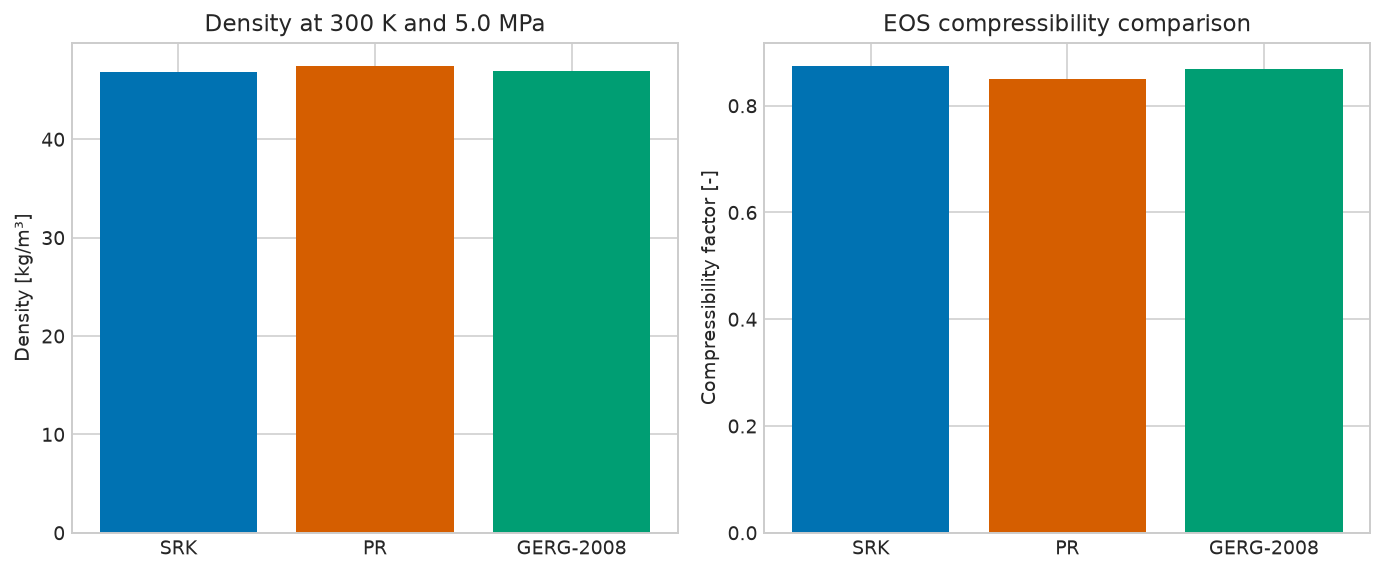

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))

axes[0].bar(
    model_table["Model"],
    model_table["Density [kg/m³]"],
    color=["#0072B2", "#D55E00", "#009E73"],
)
axes[0].set_ylabel("Density [kg/m³]")
axes[0].set_title("Density at 300 K and 5.0 MPa")

axes[1].bar(
    model_table["Model"],
    model_table["Compressibility factor [-]"],
    color=["#0072B2", "#D55E00", "#009E73"],
)
axes[1].set_ylabel("Compressibility factor [-]")
axes[1].set_title("EOS compressibility comparison")

figure.tight_layout()
plt.show()

## 6. Multiphase equilibrium and component closure

Cooling the same gas to 260 K at 5.0 MPa creates gas and hydrocarbon-liquid phases. Overall
composition must be recovered from phase fractions $\beta_\alpha$ and phase compositions
$x_{i,\alpha}$:

$$
z_i=\sum_{\alpha}\beta_{\alpha}x_{i,\alpha}
$$

This balance is a robust way to validate phase extraction. Code should query phase names or types;
fixed phase indices are unsafe because phase ordering can change.

In [8]:
cold_state = make_natural_gas(
    temperature_kelvin=260.0,
    pressure_bara=50.0,
)
run_tp_flash(cold_state)

phase_fraction_table = pd.DataFrame(
    [
        {
            "Phase": str(cold_state.getPhase(index).getPhaseTypeName()),
            "Molar phase fraction [mol/mol]": cold_state.getBeta(index),
            "Density [kg/m³]": cold_state.getPhase(index).getDensity("kg/m3"),
        }
        for index in range(cold_state.getNumberOfPhases())
    ]
)

component_closure_records = []
for component_index in range(cold_state.getNumberOfComponents()):
    component = cold_state.getPhase(0).getComponent(component_index)
    component_name = str(component.getName())
    overall_fraction = component.getz()
    reconstructed_fraction = sum(
        cold_state.getBeta(phase_index)
        * cold_state.getPhase(phase_index).getComponent(component_index).getx()
        for phase_index in range(cold_state.getNumberOfPhases())
    )
    component_closure_records.append(
        {
            "Component": component_name,
            "Overall z [mol/mol]": overall_fraction,
            "Reconstructed z [mol/mol]": reconstructed_fraction,
            "Residual [mol/mol]": reconstructed_fraction - overall_fraction,
        }
    )

component_closure_table = pd.DataFrame(component_closure_records)
maximum_component_residual = float(
    component_closure_table["Residual [mol/mol]"].abs().max()
)

print(phase_fraction_table.round(6).to_string(index=False))
print(component_closure_table.to_string(index=False))
print(f"Maximum component residual: {maximum_component_residual:.3e} mol/mol")

Phase  Molar phase fraction [mol/mol]  Density [kg/m³]
  gas                        0.982744        59.523000
  oil                        0.017256       485.763802
Component  Overall z [mol/mol]  Reconstructed z [mol/mol]  Residual [mol/mol]
 nitrogen                 0.02                       0.02                 0.0
      CO2                 0.03                       0.03                 0.0
  methane                 0.80                       0.80                 0.0
   ethane                 0.09                       0.09                 0.0
  propane                 0.04                       0.04                 0.0
 n-butane                 0.02                       0.02                 0.0
Maximum component residual: 0.000e+00 mol/mol


## 7. PS and PH flashes

A PS flash finds temperature at fixed pressure and entropy; it provides the reversible adiabatic
reference used by compressors and expanders. A PH flash finds temperature and phases at fixed
pressure and enthalpy; it is used for heaters, coolers, valves, and energy-balance specifications.

The checks are

$$
S_{2s}=S_1
$$

and

$$
H_{2}=H_1
$$

using the same extensive basis before and after each flash.

In [9]:
reference_state = make_natural_gas(
    temperature_kelvin=303.15,
    pressure_bara=40.0,
)
run_tp_flash(reference_state)

reference_enthalpy_j = reference_state.getEnthalpy()
reference_entropy_j_per_k = reference_state.getEntropy()

isentropic_state = reference_state.clone()
isentropic_state.setPressure(80.0, "bara")
ThermodynamicOperations(isentropic_state).PSflash(reference_entropy_j_per_k)
isentropic_state.initProperties()

isenthalpic_state = reference_state.clone()
isenthalpic_state.setPressure(20.0, "bara")
ThermodynamicOperations(isenthalpic_state).PHflash(reference_enthalpy_j)
isenthalpic_state.initProperties()

entropy_residual_j_per_k = (
    isentropic_state.getEntropy() - reference_entropy_j_per_k
)
enthalpy_residual_j = (
    isenthalpic_state.getEnthalpy() - reference_enthalpy_j
)

flash_table = pd.DataFrame(
    {
        "State": ["Reference", "PS compression", "PH expansion"],
        "Temperature [K]": [
            reference_state.getTemperature("K"),
            isentropic_state.getTemperature("K"),
            isenthalpic_state.getTemperature("K"),
        ],
        "Pressure [MPa abs]": [
            reference_state.getPressure("bara") * 0.1,
            isentropic_state.getPressure("bara") * 0.1,
            isenthalpic_state.getPressure("bara") * 0.1,
        ],
        "Phases [-]": [
            reference_state.getNumberOfPhases(),
            isentropic_state.getNumberOfPhases(),
            isenthalpic_state.getNumberOfPhases(),
        ],
    }
)

print(flash_table.round(5).to_string(index=False))
print(f"PS entropy residual: {entropy_residual_j_per_k:.3e} J/K")
print(f"PH enthalpy residual: {enthalpy_residual_j:.3e} J")

         State  Temperature [K]  Pressure [MPa abs]  Phases [-]
     Reference        303.15000                 4.0           1
PS compression        354.05885                 8.0           1
  PH expansion        291.81193                 2.0           1
PS entropy residual: -1.066e-14 J/K
PH enthalpy residual: 1.355e-08 J


## 8. Limiting case and state independence

At low pressure and elevated temperature, intermolecular effects become small and the gas should
approach the ideal-gas limit $Z\rightarrow1$. A fresh low-pressure fluid also proves that changing
the earlier cold state did not alter the reusable composition or base state.

In [10]:
ideal_limit_state = make_natural_gas(
    temperature_kelvin=350.0,
    pressure_bara=1.01325,
)
run_tp_flash(ideal_limit_state)

ideal_limit_z = ideal_limit_state.getZ()
base_state_unchanged = (
    abs(base_state.getTemperature("K") - 300.0) < 1.0e-12
    and abs(base_state.getPressure("bara") - 50.0) < 1.0e-12
)

print(f"Low-pressure compressibility factor: {ideal_limit_z:.7f}")
print(f"Original base state unchanged: {base_state_unchanged}")

Low-pressure compressibility factor: 0.9985552
Original base state unchanged: True


## 9. Deterministic property grid

A small grid replaces the old random 15,000-flash benchmark. Deterministic inputs are reproducible,
quick to inspect, and useful for testing expected trends. Every grid point creates a fresh SRK
fluid and performs a TP flash.

In [11]:
grid_temperatures_kelvin = [280.0, 300.0, 320.0]
grid_pressures_bara = [1.01325, 20.0, 50.0, 100.0]
property_grid_records = []

for temperature_kelvin in grid_temperatures_kelvin:
    for pressure_bara in grid_pressures_bara:
        grid_state = make_natural_gas(
            temperature_kelvin=temperature_kelvin,
            pressure_bara=pressure_bara,
        )
        run_tp_flash(grid_state)

        property_grid_records.append(
            {
                "Temperature [K]": temperature_kelvin,
                "Pressure [MPa abs]": pressure_bara * 0.1,
                "Compressibility factor [-]": grid_state.getZ(),
                "Density [kg/m³]": grid_state.getDensity("kg/m3"),
                "Number of phases [-]": grid_state.getNumberOfPhases(),
            }
        )

property_grid = pd.DataFrame(property_grid_records)
print(property_grid.round(5).to_string(index=False))

 Temperature [K]  Pressure [MPa abs]  Compressibility factor [-]  Density [kg/m³]  Number of phases [-]
           280.0             0.10132                     0.99666          0.88862                     1
           280.0             2.00000                     0.93338         18.74992                     1
           280.0             5.00000                     0.83287         52.64269                     1
           280.0            10.00000                     0.69696        126.39472                     1
           300.0             0.10132                     0.99737          0.82878                     1
           300.0             2.00000                     0.94841         17.22108                     1
           300.0             5.00000                     0.87406         46.80101                     1
           300.0            10.00000                     0.77686        105.69891                     1
           320.0             0.10132                     0.99793

Density should increase strongly with pressure. The $Z$ trend is nonlinear and model-dependent,
so it is interpreted rather than forced to be monotonic. All grid states remain finite and within
the stated teaching envelope.

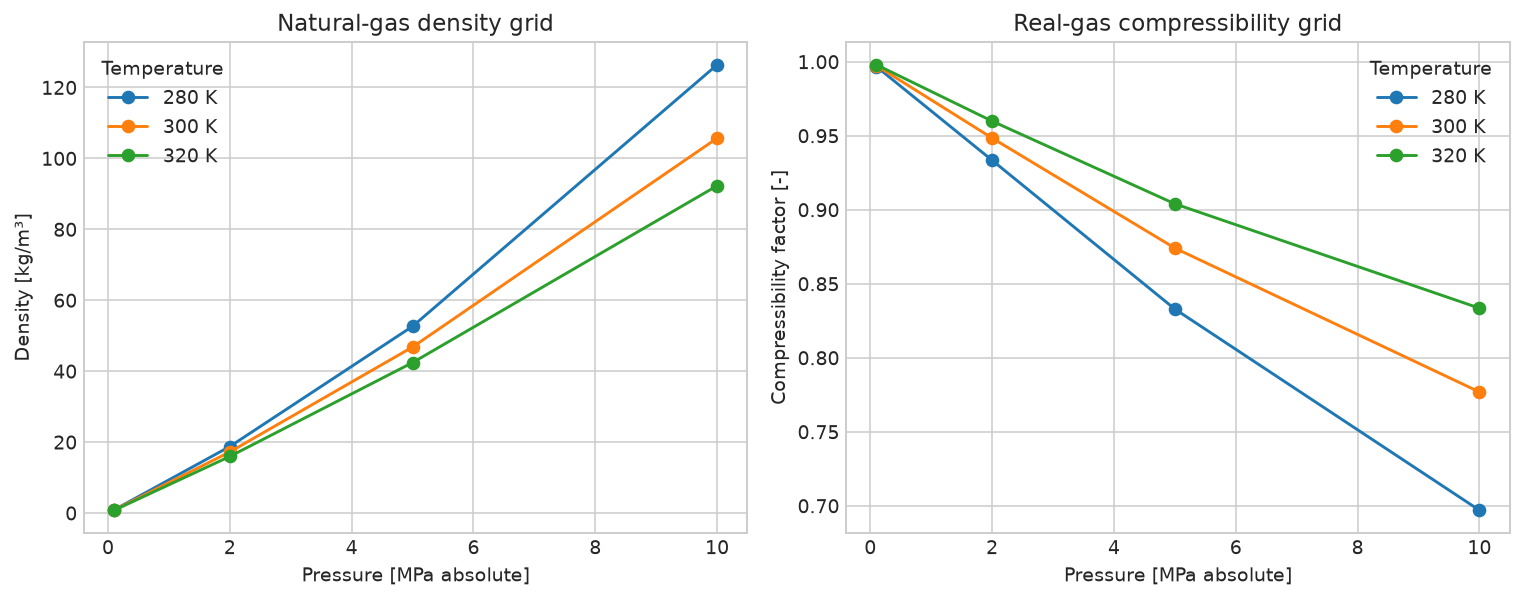

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))

for temperature_kelvin, group in property_grid.groupby("Temperature [K]"):
    label = f"{temperature_kelvin:.0f} K"
    axes[0].plot(
        group["Pressure [MPa abs]"],
        group["Density [kg/m³]"],
        marker="o",
        label=label,
    )
    axes[1].plot(
        group["Pressure [MPa abs]"],
        group["Compressibility factor [-]"],
        marker="o",
        label=label,
    )

axes[0].set_xlabel("Pressure [MPa absolute]")
axes[0].set_ylabel("Density [kg/m³]")
axes[0].set_title("Natural-gas density grid")
axes[0].legend(title="Temperature")

axes[1].set_xlabel("Pressure [MPa absolute]")
axes[1].set_ylabel("Compressibility factor [-]")
axes[1].set_title("Real-gas compressibility grid")
axes[1].legend(title="Temperature")

figure.tight_layout()
plt.show()

## 10. Connecting thermodynamics to a process flowsheet

The process heats 0.5 kg/s of gas, compresses it from 3.0 to 8.0 MPa absolute at 78% isentropic
efficiency, and cools it to 310 K. The compressor efficiency is

$$
\eta_s=\frac{h_{2s}-h_1}{h_2-h_1}
$$

where $h_{2s}$ is the isentropic outlet enthalpy and $h_2$ is the actual outlet enthalpy. The
chosen efficiency is a realistic teaching input, not a vendor guarantee.

In [13]:
clearProcess()

mass_flow_kg_per_s = 0.5
process_fluid = make_natural_gas(
    temperature_kelvin=300.0,
    pressure_bara=30.0,
)
feed_stream = stream("natural gas feed", process_fluid)
feed_stream.setFlowRate(mass_flow_kg_per_s, "kg/sec")

process_heater = heater("feed heater", feed_stream)
process_heater.setOutTemperature(320.0, "K")

process_compressor = compressor(
    "export compressor",
    process_heater.getOutletStream(),
    80.0,
)
process_compressor.setIsentropicEfficiency(0.78)

process_cooler = cooler(
    "export aftercooler",
    process_compressor.getOutletStream(),
)
process_cooler.setOutTemperature(310.0, "K")

runProcess()

process_results = pd.DataFrame(
    {
        "Quantity": [
            "Feed mass flow",
            "Heater duty",
            "Compressor power",
            "Compressor outlet temperature",
            "Cooler duty",
            "Final temperature",
            "Final pressure",
        ],
        "Value": [
            feed_stream.getFlowRate("kg/sec"),
            process_heater.getDuty("kW"),
            process_compressor.getPower("kW"),
            process_compressor.getOutletStream().getTemperature("K"),
            process_cooler.getDuty("kW"),
            process_cooler.getOutletStream().getTemperature("K"),
            process_cooler.getOutletStream().getPressure("bara") * 0.1,
        ],
        "Unit": [
            "kg/s",
            "kW",
            "kW",
            "K",
            "kW",
            "K",
            "MPa absolute",
        ],
    }
)

print(process_results.round(6).to_string(index=False))

                     Quantity       Value         Unit
               Feed mass flow    0.500000         kg/s
                  Heater duty   22.108292           kW
             Compressor power   86.182718           kW
Compressor outlet temperature  407.829558            K
                  Cooler duty -126.395663           kW
            Final temperature  310.000000            K
               Final pressure    8.000000 MPa absolute


## 11. Mass and energy balances

For the overall steady process, neglecting kinetic and potential energy,

$$
\dot Q+\dot W_{\mathrm{in}}
=\dot m(h_{\mathrm{out}}-h_{\mathrm{in}})
$$

Heater and cooler duties retain NeqSim's sign: positive heat enters the fluid. Compressor power is
positive work entering the fluid. Mass flow must remain unchanged through every unit.

In [14]:
final_stream = process_cooler.getOutletStream()
inlet_enthalpy_kj_per_kg = feed_stream.getThermoSystem().getEnthalpy("kJ/kg")
outlet_enthalpy_kj_per_kg = final_stream.getThermoSystem().getEnthalpy("kJ/kg")

total_energy_input_kw = (
    process_heater.getDuty("kW")
    + process_compressor.getPower("kW")
    + process_cooler.getDuty("kW")
)
stream_enthalpy_change_kw = mass_flow_kg_per_s * (
    outlet_enthalpy_kj_per_kg - inlet_enthalpy_kj_per_kg
)
process_energy_residual_kw = (
    total_energy_input_kw - stream_enthalpy_change_kw
)
process_mass_residual_kg_per_s = (
    final_stream.getFlowRate("kg/sec")
    - feed_stream.getFlowRate("kg/sec")
)

print(f"Overall energy residual: {process_energy_residual_kw:.3e} kW")
print(f"Overall mass residual: {process_mass_residual_kg_per_s:.3e} kg/s")

Overall energy residual: 0.000e+00 kW
Overall mass residual: 0.000e+00 kg/s


## 12. Compressor pressure sensitivity

Each case rebuilds the stream and compressor from the same 300 K, 3.0 MPa inlet. Power and outlet
temperature should increase as discharge pressure increases. The study isolates thermodynamic
effects; it does not include compressor maps, speed limits, surge, mechanical losses, or driver
efficiency.

In [15]:
discharge_pressures_bara = [50.0, 65.0, 80.0, 95.0]
compressor_sensitivity_records = []

for discharge_pressure_bara in discharge_pressures_bara:
    clearProcess()

    scenario_fluid = make_natural_gas(
        temperature_kelvin=300.0,
        pressure_bara=30.0,
    )
    scenario_feed = stream("sensitivity feed", scenario_fluid)
    scenario_feed.setFlowRate(mass_flow_kg_per_s, "kg/sec")

    scenario_compressor = compressor(
        "sensitivity compressor",
        scenario_feed,
        discharge_pressure_bara,
    )
    scenario_compressor.setIsentropicEfficiency(0.78)
    runProcess()

    compressor_sensitivity_records.append(
        {
            "Discharge pressure [MPa abs]": discharge_pressure_bara * 0.1,
            "Power [kW]": scenario_compressor.getPower("kW"),
            "Outlet temperature [K]": (
                scenario_compressor.getOutletStream().getTemperature("K")
            ),
        }
    )

compressor_sensitivity_table = pd.DataFrame(compressor_sensitivity_records)
print(compressor_sensitivity_table.round(5).to_string(index=False))

 Discharge pressure [MPa abs]  Power [kW]  Outlet temperature [K]
                          5.0    39.22004               343.42357
                          6.5    61.18804               366.65617
                          8.0    79.55932               385.45156
                          9.5    95.48573               401.26265


The sensitivity plot makes both monotonic trends visible. The axes remain separate because power
and temperature are different physical quantities.

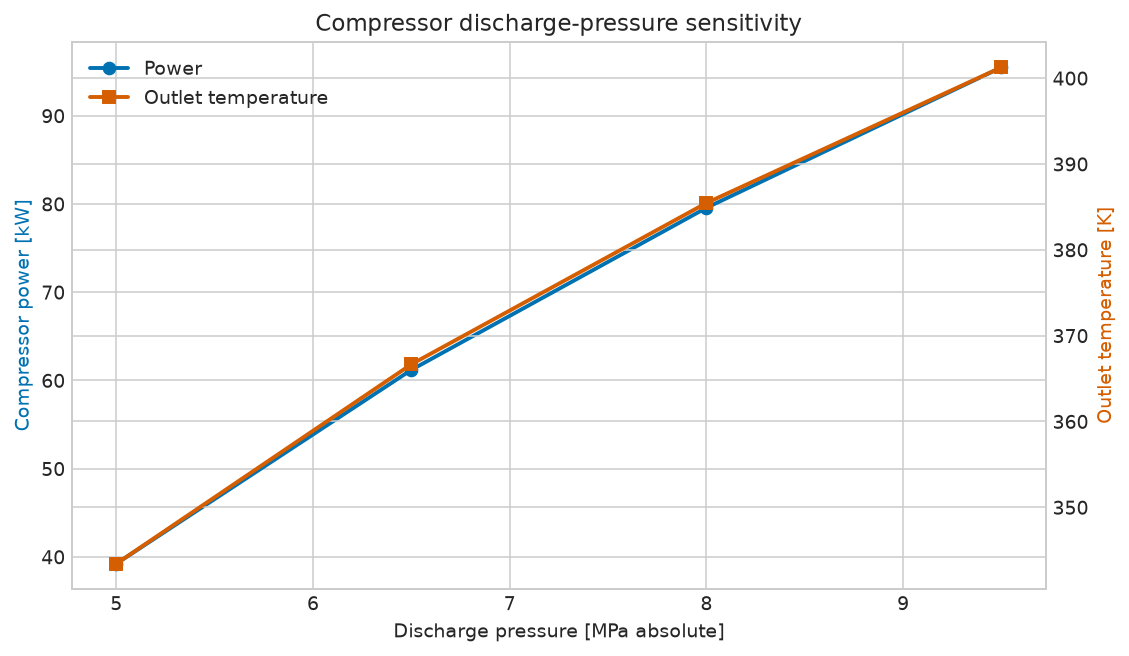

In [16]:
figure, power_axis = plt.subplots(figsize=(8.2, 4.8))
temperature_axis = power_axis.twinx()

power_axis.plot(
    compressor_sensitivity_table["Discharge pressure [MPa abs]"],
    compressor_sensitivity_table["Power [kW]"],
    color="#0072B2",
    marker="o",
    linewidth=2.0,
    label="Power",
)
temperature_axis.plot(
    compressor_sensitivity_table["Discharge pressure [MPa abs]"],
    compressor_sensitivity_table["Outlet temperature [K]"],
    color="#D55E00",
    marker="s",
    linewidth=2.0,
    label="Outlet temperature",
)

power_axis.set_xlabel("Discharge pressure [MPa absolute]")
power_axis.set_ylabel("Compressor power [kW]", color="#0072B2")
temperature_axis.set_ylabel("Outlet temperature [K]", color="#D55E00")
power_axis.set_title("Compressor discharge-pressure sensitivity")

lines = power_axis.get_lines() + temperature_axis.get_lines()
labels = [line.get_label() for line in lines]
power_axis.legend(lines, labels, loc="upper left")

figure.tight_layout()
plt.show()

## 13. Verification checks

The assertions cover inputs, thermodynamic identities, phase and component closure, limiting
behaviour, deterministic-grid finiteness, flash specifications, process balances, and sensitivity
trends. Tolerances distinguish numerical closure from model uncertainty.

In [17]:
model_numeric_values = model_table.select_dtypes(include=[float, int]).to_numpy()
grid_numeric_values = property_grid.select_dtypes(include=[float, int]).to_numpy()
grid_densities = property_grid["Density [kg/m³]"].to_numpy().reshape(3, 4)
compressor_powers_kw = compressor_sensitivity_table["Power [kW]"].to_numpy()
compressor_temperatures_kelvin = compressor_sensitivity_table[
    "Outlet temperature [K]"
].to_numpy()

verification_checks = {
    "NeqSim version recorded": bool(neqsim_version),
    "composition normalized": abs(composition_sum - 1.0) < 1.0e-12,
    "base state is gas": phase_names == ["gas"],
    "base properties finite": bool(
        np.isfinite(
            [
                base_state.getZ(),
                base_state.getDensity("kg/m3"),
                base_state.getCp("J/molK"),
            ]
        ).all()
    ),
    "positive density": density_kg_per_m3 > 0.0,
    "density identity": abs(density_identity_residual) < 1.0e-10,
    "stable heat capacities": gas_phase.getCp("J/molK") > gas_phase.getCv("J/molK") > 0.0,
    "positive transport properties": (
        gas_phase.getViscosity("kg/msec") > 0.0
        and gas_phase.getThermalConductivity("W/mK") > 0.0
    ),
    "model comparison finite": bool(np.isfinite(model_numeric_values).all()),
    "cubic density spread bounded": float(
        model_table["Density difference from GERG-2008 [%]"].abs().max()
    ) < 2.0,
    "cold state is two phase": cold_state.getNumberOfPhases() == 2,
    "phase fractions close": abs(
        phase_fraction_table["Molar phase fraction [mol/mol]"].sum() - 1.0
    ) < 1.0e-12,
    "component closure": maximum_component_residual < 1.0e-12,
    "PS entropy closure": abs(entropy_residual_j_per_k) < 1.0e-8,
    "PH enthalpy closure": abs(enthalpy_residual_j) < 1.0e-5,
    "isentropic compression heats gas": (
        isentropic_state.getTemperature("K") > reference_state.getTemperature("K")
    ),
    "ideal-gas limiting case": abs(ideal_limit_z - 1.0) < 0.01,
    "base state independent": base_state_unchanged,
    "property grid finite": bool(np.isfinite(grid_numeric_values).all()),
    "density increases with pressure": bool(
        np.all(np.diff(grid_densities, axis=1) > 0.0)
    ),
    "process mass closure": abs(process_mass_residual_kg_per_s) < 1.0e-12,
    "process energy closure": abs(process_energy_residual_kw) < 1.0e-9,
    "compressor power positive": process_compressor.getPower("kW") > 0.0,
    "compressor power monotonic": bool(np.all(np.diff(compressor_powers_kw) > 0.0)),
    "compressor temperature monotonic": bool(
        np.all(np.diff(compressor_temperatures_kelvin) > 0.0)
    ),
}

failed_checks = [
    check_name
    for check_name, passed in verification_checks.items()
    if not passed
]

assert not failed_checks, f"Failed checks: {failed_checks}"
print(f"All {len(verification_checks)} engineering checks passed.")

All 25 engineering checks passed.


## 14. Troubleshooting and applicability

- **Import fails:** run the setup cell once, then rerun imports; do not inject a local JAR.
- **Wrong phase count:** check absolute pressure, temperature units, composition normalization, model,
  mixing rule, and `setMultiPhaseCheck(True)`.
- **Property unavailable:** complete the flash and call `initProperties()` before reading transport
  or caloric properties.
- **Phase-index error:** query phase type or name instead of assuming gas is index 0.
- **PH or PS result is unexpected:** preserve the extensive enthalpy or entropy basis, set the new
  pressure before the flash, and compare the residual after convergence.
- **Process result changes between cases:** call `clearProcess()` and create fresh fluids and streams.

This notebook is a screening and teaching workflow. EOS and transport-correlation selection,
binary parameters, plus-fraction characterization, water/electrolyte chemistry, equipment maps,
pressure loss, heat-transfer design, dynamics, control, relief, materials, and safety analysis need
additional models and project-specific validation.

## 15. Summary, exercises, and references

The revised workflow creates fresh compositional fluids, makes units explicit, separates flexible
multiphase cubic models from gas-phase GERG-2008, verifies three flash types, closes component and
process balances, and connects property calculations to a small flowsheet. Reproducibility comes
from deterministic inputs, named intermediate results, assertions, and clean execution order.

**Further exercises**

1. Add water and compare SRK with CPA, explaining the different association treatment.
2. Replace the synthetic composition with a normalized public gas analysis.
3. Add a valve after the cooler and verify an isenthalpic pressure reduction.
4. Add compressor efficiency sensitivity and separate shaft power from driver energy.
5. Generate a phase envelope and mark each process state against it.

**Authoritative references**

- [NeqSim thermodynamic model selection](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [NeqSim reading fluid properties](https://equinor.github.io/neqsim/thermo/reading_fluid_properties.html)
- [NeqSim thermodynamics recipes](https://equinor.github.io/neqsim/cookbook/thermodynamics-recipes.html)
- [NeqSim process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)
- [GERG-2008 reference equation publication](https://doi.org/10.1021/je300655b)

Documentation and release references were checked on 20 July 2026. Recheck them and the installed
NeqSim version before using results in engineering decisions.